## Imports

In [1]:
import mesmer
import model
import model_analysis

import importlib
import matplotlib.pyplot as plt
import xarray as xr

import numpy as np

import cartopy.crs as ccrs



### Updates (temp)

In [2]:
importlib.reload(model.stats);
importlib.reload(model.shape_data);
importlib.reload(model.transform);



## Load Data

In [3]:
is_local_data = True

In [4]:
mean_mrsol_ds = model.shape_data.load_data_set(var = "mrsol", local = is_local_data, run_idx=1)
mean_mrsol_ds = model.shape_data.prune_group_ds_timespan(mean_mrsol_ds,Month_idx=1).drop_vars("depth_bnds")

var_mrsol_ds = model.shape_data.load_data_set(var = "mrsol", local = is_local_data, run_idx=2)
var_mrsol_ds = model.shape_data.prune_group_ds_timespan(var_mrsol_ds,Month_idx=1).drop_vars("depth_bnds")

#Wenn man sicher gehen will, das der Predictor die testdaten nicht kennen soll, kann man die testdaten auch erst nach dem Calibrieren berechnen
test_mrsol_ds = model.shape_data.load_data_set(var = "mrsol", local = is_local_data, run_idx=3)
test_mrsol_ds = model.shape_data.prune_group_ds_timespan(test_mrsol_ds,Month_idx=1).drop_vars("depth_bnds")

In [5]:
tas_ds = model.shape_data.load_data_set(var = "tas", local = is_local_data, run_idx=1)
pr_ds = model.shape_data.load_data_set(var = "pr", local = is_local_data, run_idx=1)
tas_ds = model.shape_data.prune_group_ds_timespan(tas_ds,Month_idx=1)
pr_ds = model.shape_data.prune_group_ds_timespan(pr_ds,Month_idx=1)

mean_input_ds = xr.merge([tas_ds,pr_ds]).drop_vars("file_qf")

tas_ds = model.shape_data.load_data_set(var = "tas", local = is_local_data, run_idx=2)
pr_ds = model.shape_data.load_data_set(var = "pr", local = is_local_data, run_idx=2)
tas_ds = model.shape_data.prune_group_ds_timespan(tas_ds,Month_idx=1)
pr_ds = model.shape_data.prune_group_ds_timespan(pr_ds,Month_idx=1)

var_input_ds = xr.merge([tas_ds,pr_ds]).drop_vars("file_qf")

tas_ds = model.shape_data.load_data_set(var = "tas", local = is_local_data, run_idx=3)
pr_ds = model.shape_data.load_data_set(var = "pr", local = is_local_data, run_idx=3)
tas_ds = model.shape_data.prune_group_ds_timespan(tas_ds,Month_idx=1)
pr_ds = model.shape_data.prune_group_ds_timespan(pr_ds,Month_idx=1)

test_input_ds = xr.merge([tas_ds,pr_ds]).drop_vars("file_qf")


### Mask and Stack Data

In [6]:
mean_mrsol_masked_ds, chunk_mask, detail_mask_mean = model.mask.mask_nonpositiv_height_chunks(mean_mrsol_ds)
mean_input_masked_ds = model.mask.mask_mask(mean_input_ds,chunk_mask)

var_mrsol_masked_ds , chunk_mask_var, detail_mask_mean = model.mask.mask_nonpositiv_height_chunks(var_mrsol_ds)
var_input_masked_ds = model.mask.mask_mask(var_input_ds,chunk_mask)

test_mrsol_masked_ds, chunk_mask_test, detail_mask_mean= model.mask.mask_nonpositiv_height_chunks(test_mrsol_ds)
test_input_masked_ds = model.mask.mask_mask(test_input_ds,chunk_mask)

In [7]:
#The chunk_mask schould all be the same, this is important that there are no shape problems in the regressions, you can test this with  
#(chunk_mask != chunk_mask_2).sum(),#(chunk_mask != chunk_mask_1).sum(),
#The chunk_mask is used, that the regression can predict a depth.size vector at each gridcell, the masks: detail_mask_mean, detail_mask_var and detail_mask_test are later used to determan which points are real predictions and witch where just placeholders to let the regression run smoothly.

In [8]:
mean_mrsol_stack_ds = mesmer.grid.stack_lat_lon(mean_mrsol_masked_ds)
var_mrsol_stack_ds = mesmer.grid.stack_lat_lon(var_mrsol_masked_ds)
test_mrsol_stack_ds = mesmer.grid.stack_lat_lon(test_mrsol_masked_ds)
mean_input_stack_ds = mesmer.grid.stack_lat_lon(mean_input_masked_ds)
var_input_stack_ds = mesmer.grid.stack_lat_lon(var_input_masked_ds)
test_input_stack_ds = mesmer.grid.stack_lat_lon(test_input_masked_ds)

### Transform Data

In [9]:
mean_mrsol_t = model.transform.Log_Transform_ds(mean_mrsol_stack_ds)
var_mrsol_t = model.transform.Log_Transform_ds(var_mrsol_stack_ds)
test_mrsol_t = model.transform.Log_Transform_ds(test_mrsol_stack_ds)

### Linaer Regression of the mean

In [10]:
mean_predictors = mean_input_stack_ds
mean_target_da = mean_mrsol_t.mrsol

In [11]:
LinReg_mean = model.stats._parallel_linear_regression.ParLinearRegression()

In [12]:
LinReg_mean.fit(predictors=mean_predictors, target=mean_target_da,location_dim="gridcell", regr_dim="time")

In [13]:
#LinReg_mean.params

### Compute Residuals for the variance

Hier wäre die meinung einen neuen Run zu verwenden, die frage ist ob sich die variance durch das fehlen des runs zu tief ausfällt. Overfitting korrektur mit 1/(1-param/n_samples)^2? (SPäter probieren)

In [14]:
var_predictors = var_input_stack_ds
var_target_ds = var_mrsol_t

In [15]:
residuals_t = LinReg_mean.residuals(var_predictors, var_target_ds)

In [16]:
residuals_t

<xarray.Dataset> Size: 3MB
Dimensions:    (depth: 5, time: 165, gridcell: 378)
Coordinates:
  * depth      (depth) float64 40B 0.03 0.19 0.78 2.68 6.98
  * time       (time) datetime64[ns] 1kB 1850-01-31 1851-01-31 ... 2014-01-31
    lat        (gridcell) float64 3kB -51.75 -47.25 -42.75 ... 78.75 78.75 78.75
    lon        (gridcell) float64 3kB 288.0 288.0 288.0 ... 270.0 279.0 297.0
    height     float64 8B 2.0
Dimensions without coordinates: gridcell
Data variables:
    residuals  (time, depth, gridcell) float64 2MB -0.0003309 ... -2.132e-14

### Linear Regression of the Variance

In [17]:
LinReg_variance = model.stats._parallel_linear_regression.ParLinearRegression()

In [18]:
LinReg_variance.fit(predictors=var_predictors, target=(residuals_t.residuals)**2,location_dim="gridcell", regr_dim="time")

### Predictor

In [19]:
LinReg_mean.params

<xarray.Dataset> Size: 51kB
Dimensions:        (gridcell: 378, depth: 5)
Coordinates:
    lat            (gridcell) float64 3kB -51.75 -47.25 -42.75 ... 78.75 78.75
    lon            (gridcell) float64 3kB 288.0 288.0 288.0 ... 279.0 297.0
  * depth          (depth) float64 40B 0.03 0.19 0.78 2.68 6.98
Dimensions without coordinates: gridcell
Data variables:
    intercept      (gridcell, depth) float64 15kB 3.965 5.803 ... -9.21 -9.21
    tas            (gridcell, depth) float64 15kB -0.005368 ... -1.437e-28
    pr             (gridcell, depth) float64 15kB 3.815e+03 ... 6.801e-23
    fit_intercept  bool 1B True

In [20]:
LinReg_mean, LinReg_variance

(<model.stats._parallel_linear_regression.ParLinearRegression at 0x7f62bcabe7b0>,
 <model.stats._parallel_linear_regression.ParLinearRegression at 0x7f62b40d42d0>)

### Export Prameters

In [21]:
#model.save.save_params(LinReg_mean.params,LinReg_variance.params,var = "mrsol",scen= "historical", folder = "MPI-ESM1-2-LR/Log-trans")

In [22]:
#model.shape_data.load_params(var = "mrsol",scen= "historical", folder = "MPI-ESM1-2-LR/Log-trans")

### Example Emulation

In [50]:
test_predictors = test_input_stack_ds
test_target_ds_t = test_mrsol_t.transpose("gridcell","time", "depth")

In [51]:
test_mean_prediction_stacked = LinReg_mean.predict(test_predictors).transpose("gridcell","time", "depth")

In [52]:
test_var_prediction_stacked = LinReg_variance.predict(test_predictors).clip(min = 1e-32).transpose("gridcell","time", "depth")

### crps(s) Score

In [53]:
#temp
importlib.reload(model_analysis.crps_score);

scheinbar wächst die laufzeit in der ensemble_size mehr als linear, sieht schlimmer als quadratisch aus:(

5->0.5s

10->1.3s

20->4.2s

40->15s

80->1min 54s

In [54]:
crps_score_stacked, space_crps_score_stacked = model_analysis.crps_score.crps_ensemble_score(test_mean_prediction_stacked, test_var_prediction_stacked,test_target_ds_t,transformation="Log",ensemble_size=10)

for both of the scors we can calculate a crpss score against the time constant mean, for the score of the backtransposed data, we need to make a non-transposed target.

In [57]:
test_target_ds = model.transform.Log_Transform_ds_inv(test_target_ds_t)

In [63]:
scores_stacked = model_analysis.crps_score.add_crpss_against_mean_ensemble_score(crps_score_stacked,test_target_ds) 

In [64]:
space_scores_stacked = model_analysis.crps_score.add_crpss_against_mean_ensemble_score(space_crps_score_stacked,test_target_ds_t) 

In [ ]:
#scores

<xarray.Dataset> Size: 21MB
Dimensions:             (lon: 40, lat: 40, depth: 5, time: 165)
Coordinates:
  * lon                 (lon) float64 320B 0.0 9.0 18.0 ... 333.0 342.0 351.0
  * lat                 (lat) float64 320B -87.75 -83.25 -78.75 ... 83.25 87.75
  * depth               (depth) float64 40B 0.03 0.19 0.78 2.68 6.98
  * time                (time) datetime64[ns] 1kB 1850-01-31 ... 2014-01-31
Data variables:
    crps_score          (depth, time, lat, lon) float64 11MB nan nan ... nan nan
    const_mean_crps     (time, depth, lat, lon) float64 11MB nan nan ... nan nan
    crpss_against_mean  (depth, lat, lon) float64 64kB nan nan nan ... nan nan

To visualize the results we bring it back to the lat lon grid form. Ausserdem entnehmen wir die Stellen wieder, die mit threshholds aufgefüllt wurden

In [73]:
scores = mesmer.grid.unstack_lat_lon_and_align(scores_stacked,mean_mrsol_masked_ds)
space_scores = mesmer.grid.unstack_lat_lon_and_align(space_scores_stacked,mean_mrsol_masked_ds)

In [74]:
scores = model.mask.mask_mask(scores,detail_mask_mean, "lon","lat", "depth")
space_scores = model.mask.mask_mask(space_scores,detail_mask_mean, "lon","lat", "depth")

Globale Score übersicht

Text(0.5, 1.0, 'crpss_score against const mean')

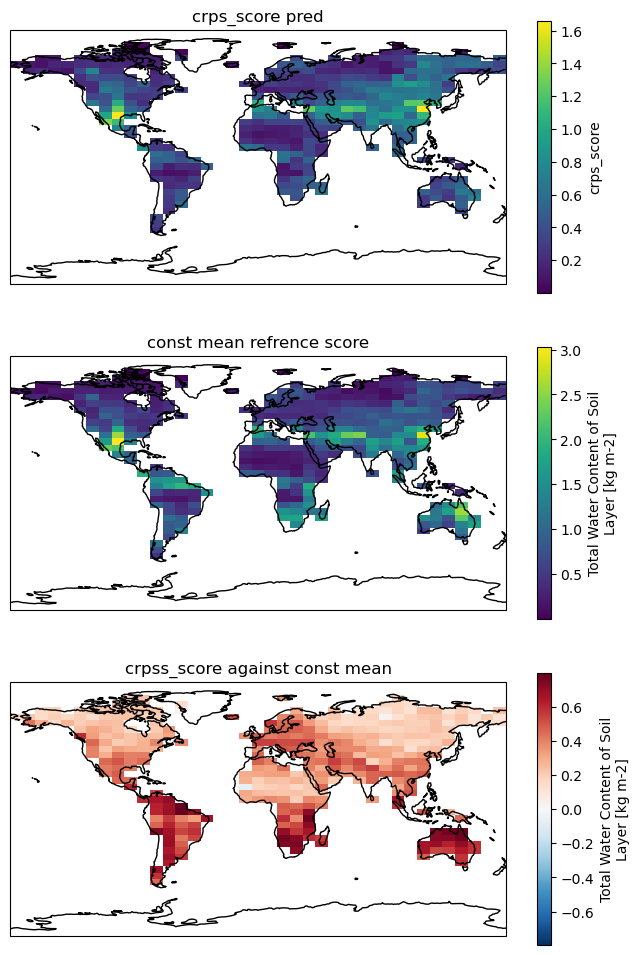

In [81]:
fig, ax = plt.subplots(
    subplot_kw={"projection": ccrs.PlateCarree()},
    nrows=3,
    ncols=1,
    figsize=(8, 12)
)

da = scores.isel(depth=0).mean("time").crps_score
da.plot(ax=ax[0])
ax[0].coastlines()
ax[0].set_title("crps_score pred")

da = scores.isel(depth=0).mean("time").const_mean_crps
da.plot(ax=ax[1])
ax[1].coastlines()
ax[1].set_title("const mean refrence score")

da = scores.isel(depth=0).mean("time").crpss_against_mean
da.plot(ax=ax[2])
ax[2].coastlines()
ax[2].set_title("crpss_score against const mean")



Text(0.5, 1.0, 'crpss_score against const mean')

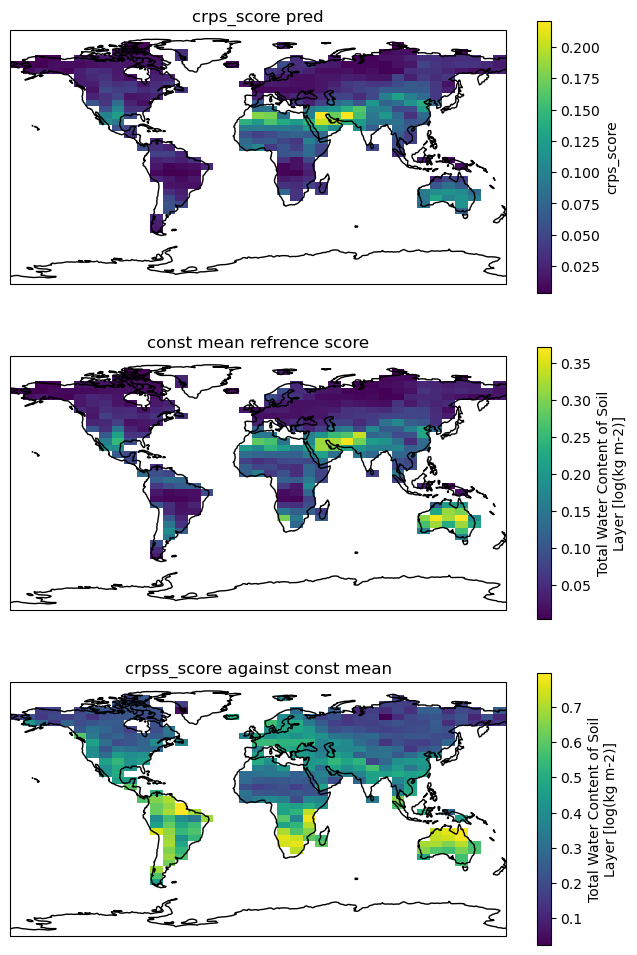

In [82]:
fig, ax = plt.subplots(
    subplot_kw={"projection": ccrs.PlateCarree()},
    nrows=3,
    ncols=1,
    figsize=(8, 12)
)

da = space_scores.isel(depth=0).mean("time").crps_score
da.plot(ax=ax[0])
ax[0].coastlines()
ax[0].set_title("crps_score pred")

da = space_scores.isel(depth=0).mean("time").const_mean_crps
da.plot(ax=ax[1])
ax[1].coastlines()
ax[1].set_title("const mean refrence score")

da = space_scores.isel(depth=0).mean("time").crpss_against_mean
da.plot(ax=ax[2])
ax[2].coastlines()
ax[2].set_title("crpss_score against const mean")



Locale Zeit reihe

In [ ]:
#Amazonas  ca. 3° S, 65° W

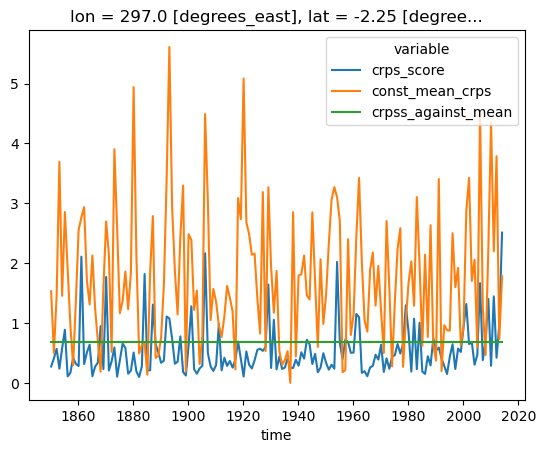

In [89]:
scores.sel(lat= -3, lon = 295, method="nearest").isel(depth = 0).to_array().plot.line(hue="variable", x = "time");

In [ ]:
#irgendwo in Russland

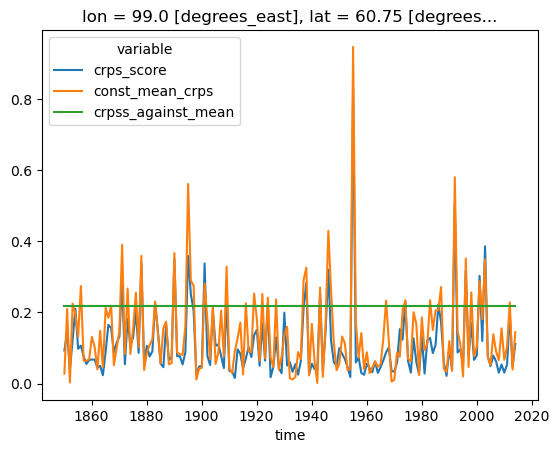

In [90]:
scores.sel(lat= 60, lon = 100, method="nearest").isel(depth = 0).to_array().plot.line(hue="variable", x = "time");

Beobachtung, was die Voraussage des Means macht temp

In [109]:
arr_targ = mesmer.grid.unstack_lat_lon_and_align(test_target_ds_t,mean_mrsol_masked_ds).sel(lat= 60, lon = 100, method="nearest").isel(depth = 0)#.to_array().plot()
#test_target_ds#.sel(lat= 60, lon = 100, method="nearest").isel(depth = 0)

In [110]:
arr_pred = mesmer.grid.unstack_lat_lon_and_align(test_mean_prediction_stacked,mean_mrsol_masked_ds).sel(lat= 60, lon = 100, method="nearest").isel(depth = 0)#.to_array().plot()

In [112]:
lul = xr.merge([arr_targ, arr_pred])

/tmp/ipykernel_1011817/43122800.py:1: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  lul = xr.merge([arr_targ, arr_pred])
/tmp/ipykernel_1011817/43122800.py:1: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  lul = xr.merge([arr_targ, arr_pred])
/tmp/ipykernel_1011817/43122800.py:1: FutureWarning: In a future version of xarray the default

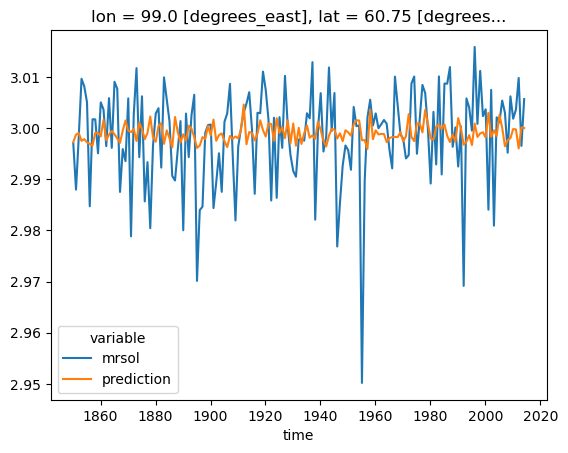

In [114]:
lul.to_array().plot.line(hue="variable", x = "time")

In [105]:
test_target_ds_t

<xarray.Dataset> Size: 3MB
Dimensions:  (time: 165, depth: 5, gridcell: 378)
Coordinates:
  * time     (time) datetime64[ns] 1kB 1850-01-31 1851-01-31 ... 2014-01-31
  * depth    (depth) float64 40B 0.03 0.19 0.78 2.68 6.98
    lat      (gridcell) float64 3kB -51.75 -47.25 -42.75 ... 78.75 78.75 78.75
    lon      (gridcell) float64 3kB 288.0 288.0 288.0 ... 270.0 279.0 297.0
Dimensions without coordinates: gridcell
Data variables:
    mrsol    (gridcell, time, depth) float64 2MB 2.693 4.083 ... -9.21 -9.21
Attributes: (12/52)
    CDI:                       Climate Data Interface version 1.9.6 (http://m...
    history:                   Wed Jul 15 10:14:30 2026: cdo remapbil,r40x40 ...
    source:                    MPI-ESM1.2-LR (2017): \naerosol: none, prescri...
    institution:               Max Planck Institute for Meteorology
    Conventions:               CF-1.7 CMIP-6.2
    activity_id:               CMIP
    ...                        ...
    cmor_version:              3.5.0
    tracking_id:               hdl:21.14100/75ec0335-3fb7-4261-a360-12d0c9337e2d
    cmip6-ng:                  \ncontact = cmip6-archive@env.ethz.ch\ndescrip...
    original_file_names:       /net/atmos/data/cmip6/historical/Emon/mrsol/MP...
    original_file_hash_codes:  3582cfa3fc76ad19b012a316199554273d631aa28a966b...
    CDO:                       Climate Data Operators version 1.9.6 (http://m...